In [71]:
import os

from torch.utils.data import Dataset, DataLoader
import torch
import torchinfo
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init

import matplotlib.pyplot as plt
import numpy as np

import albumentations as A

import SimpleITK
import SimpleITK as sitk

from collections import defaultdict
from typing import Any, Dict, Tuple
import time
import re
import random


In [72]:
BASE_DIR = "database/"  # Name of de dataset folder

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():  # mac
    device = torch.device("mps")
else:
    device = torch.device("cpu")


print("Using device:", device)

sitk.ProcessObject_SetGlobalWarningDisplay(False)

Using device: mps


## 1. FCN1:


In [ ]:
def get_file_paths(directory):
    """
    Get all file paths in a directory and its subdirectories.
    """
    file_paths = []  # creates an empty list
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths


# p: probability of applying the transformations
train_transform = A.Compose(
    [
        A.Resize(
            height=256, width=256, p=1
        ),  # re-sized all the images to 256 × 256 pixels
        A.Affine(scale=(0.9, 1.1), translate_percent=(0.1, 0.1), rotate=(-10, 10), p=1),
    ]
)

resize = A.Compose([A.Resize(height=256, width=256, p=1)])


### 1.1 FCN1 - Dataset


In [82]:
class FCN1Dataset(Dataset):
    def __init__(self, filepath, transform=None):
        self.slices = []
        self.transform = transform

        for path in filepath:
            img = self._sitk_load(path)

            mask_path = path.replace(".nii.gz", "_gt.nii.gz")
            mask = self._sitk_load(mask_path)
            mask = (mask == 3).astype(np.float32)

            # regex to find info
            patient = path.split("/")[-2]
            frame = int(re.search(r"frame(\d+)", path).group(1))

            for i in range(img.shape[0]):
                self.slices.append(
                    {
                        "image": img[i],
                        "mask": mask[i],
                        "patient": patient,
                        "frame": frame,
                        "slice_idx": i,
                    }
                )

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        item = self.slices[idx]
        img = item["image"]
        mask = item["mask"]

        if self.transform:
            augmented = self.transform(image=img, mask=mask)

            img = augmented["image"]
            mask = augmented["mask"]

        img = torch.from_numpy(img).float()
        mask = torch.from_numpy(mask).float()

        img = img.unsqueeze(0)
        mask = mask.unsqueeze(0)

        metadata = {
            "patient": item["patient"],
            "frame": item["frame"],
            "slice_idx": item["slice_idx"],
        }

        return img, mask, metadata

    def _sitk_load(
        self,
        filepath,
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        """Loads an image using SimpleITK and returns the image and its metadata.
        Args:
            filepath: Path to the image.

        Returns:
            - ([N], H, W), Image array.

        """
        # Load image and save info
        image = SimpleITK.ReadImage(str(filepath))
        # Extract numpy array from the SimpleITK image object
        im_array = np.squeeze(SimpleITK.GetArrayFromImage(image))

        return im_array


In [92]:
all_files = get_file_paths(BASE_DIR)

img_paths = [
    file
    for file in all_files
    if file.endswith(".nii.gz") and "_gt" not in file and "_4d" not in file
]
train_val_paths = [file for file in img_paths if "training" in file]


# Choose 10 random patients from pattient 001 to patiento 100 for the validation set
random.seed(42)
patients = list(range(1, 101))  # patient001 - patient100
val_patients = random.sample(patients, 10)

train_paths = []
validation_paths = []

# Extracts the patient number from the file path and checks whether that patient belongs to the validation set.
for f in train_val_paths:
    patient = int(f.split("patient")[1][:3])
    if patient in val_patients:
        validation_paths.append(f)
    else:
        train_paths.append(f)

# ------

ds_train = FCN1Dataset(train_paths, train_transform)
ds_validation = FCN1Dataset(validation_paths, resize)

test_image_paths = [file for file in img_paths if "testing" in file]
test_image_sorted = sorted(
    test_image_paths, key=lambda x: int(re.search(r"patient(\d+)", x).group(1))
)
ds_test = FCN1Dataset(test_image_sorted, resize)

### 1.2. FCN1 - Explorate data


Training length:  1694
{'patient': 'patient012', 'frame': 13, 'slice_idx': 0}

Image

Shape: torch.Size([256, 256])


Mask

Shape: torch.Size([256, 256])


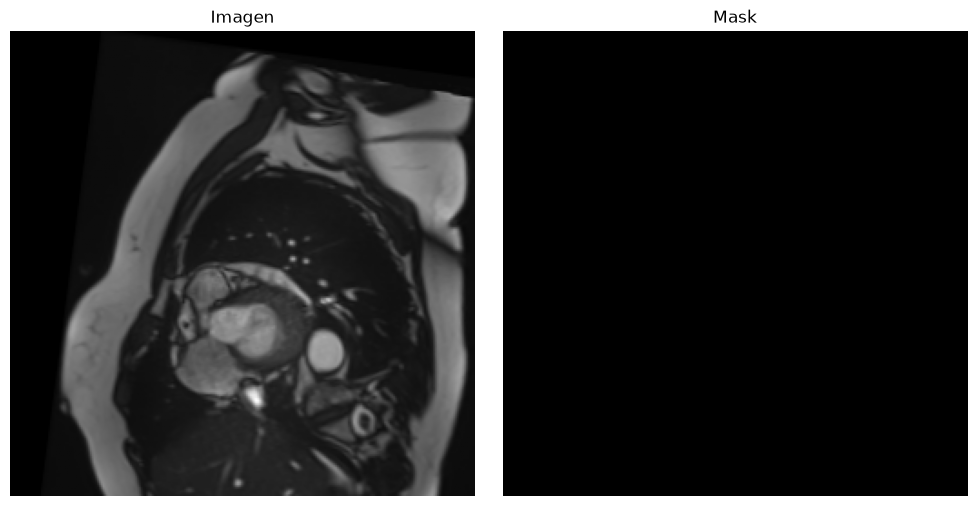

{'patient': 'patient012', 'frame': 13, 'slice_idx': 1}

Image

Shape: torch.Size([256, 256])


Mask

Shape: torch.Size([256, 256])


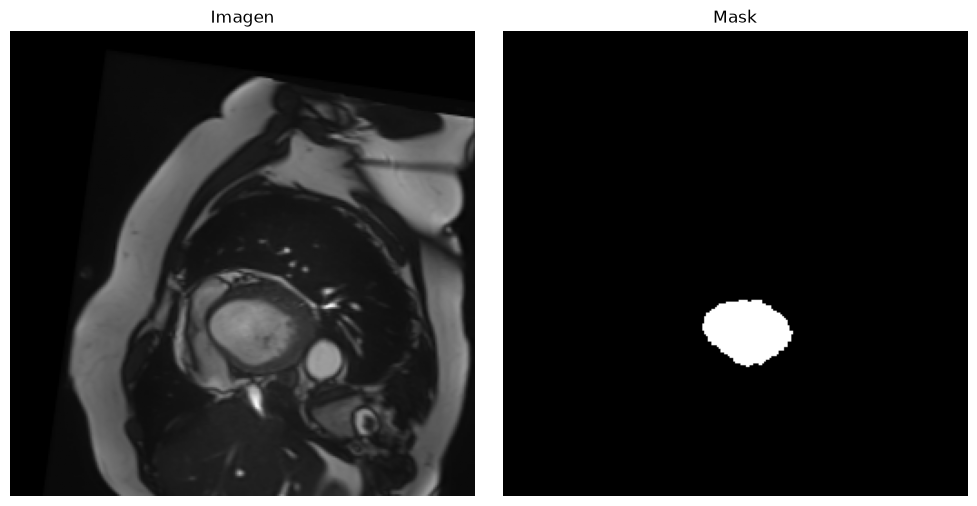

{'patient': 'patient012', 'frame': 13, 'slice_idx': 2}

Image

Shape: torch.Size([256, 256])


Mask

Shape: torch.Size([256, 256])


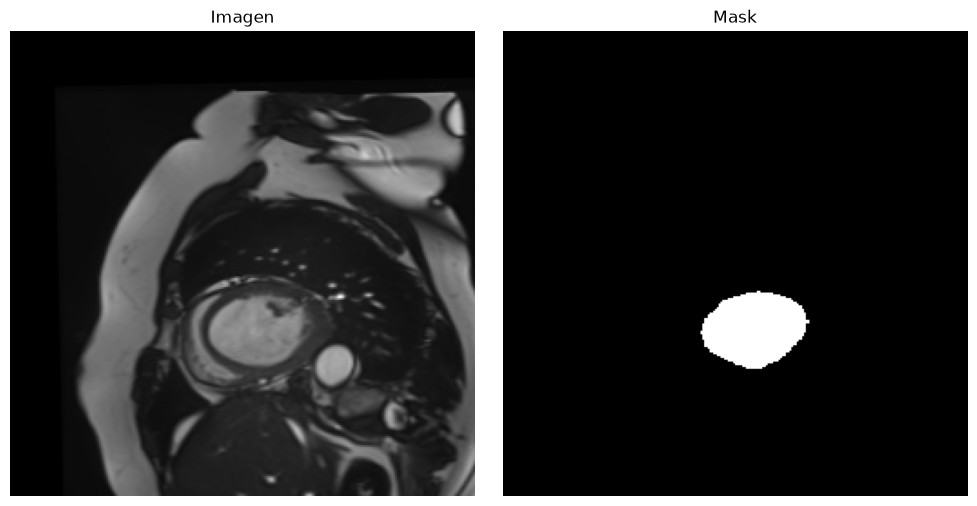

In [93]:
print("Training length: ", len(ds_train))

i = 0
for img, mask, _ in ds_train:
    print(_)
    # print(slice_idx)
    img = img.squeeze(0)
    mask = mask.squeeze(0)
    print("\nImage")
    print("\nShape:", img.shape)

    print("\n\nMask")
    print("\nShape:", mask.shape)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Imagen")
    axes[0].set_axis_off()

    axes[1].imshow(img, cmap="gray")
    axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Mask")
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()
    i = i + 1
    if i > 2:
        break


### 1.3. FCN1 - Architecture


In [94]:
class EncoderFCN1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        skip = x
        x = self.pool(x)
        return x, skip


class DecoderFCN1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Input: 512 - Output: 256
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        # Input: 256 *2 -> (because of skip connections)
        self.conv1 = nn.Conv2d(out_channels * 2, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, skip):
        x = self.upconv(x)
        # dim = 1: Concatenate along the channel dimension.
        x = torch.cat((x, skip), dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x


class FCN1Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder1 = EncoderFCN1(1, 32)
        self.encoder2 = EncoderFCN1(32, 64)
        self.encoder3 = EncoderFCN1(64, 128)
        self.encoder4 = EncoderFCN1(128, 256)

        # Bottleneck
        self.bottleneck1 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn_b1 = nn.BatchNorm2d(512)
        # bottleneck2
        self.bottleneck2 = nn.Conv2d(512, 512, 3, padding=1)
        self.bn_b2 = nn.BatchNorm2d(512)
        self.relu = nn.ReLU()

        # Decoder
        self.decode1 = DecoderFCN1(512, 256)
        self.decode2 = DecoderFCN1(256, 128)
        self.decode3 = DecoderFCN1(128, 64)
        self.decode4 = DecoderFCN1(64, 32)

        self.final_conv = nn.Conv2d(32, 1, 3, padding=1)

        # init weights AFTER all layers exist
        self.apply(self.init_weights)

    def forward(self, x):
        x, s1 = self.encoder1(x)
        x, s2 = self.encoder2(x)
        x, s3 = self.encoder3(x)
        x, s4 = self.encoder4(x)

        x = self.bottleneck1(x)
        x = self.bn_b1(x)
        x = self.relu(x)
        x = self.bottleneck2(x)
        x = self.bn_b2(x)
        x = self.relu(x)

        x = self.decode1(x, s4)
        x = self.decode2(x, s3)
        x = self.decode3(x, s2)
        x = self.decode4(x, s1)

        x = self.final_conv(x)
        return x

    # TODO: revisar bien
    def init_weights(self, m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            init.kaiming_normal_(m.weight, nonlinearity="relu")

In [95]:
img_size = (256, 256)
batch_size = 8

torchinfo.summary(FCN1Net(), input_size=(batch_size, 1, img_size[0], img_size[1]))

Layer (type:depth-idx)                   Output Shape              Param #
FCN1Net                                  [8, 1, 256, 256]          --
├─EncoderFCN1: 1-1                       [8, 32, 128, 128]         --
│    └─Conv2d: 2-1                       [8, 32, 256, 256]         320
│    └─BatchNorm2d: 2-2                  [8, 32, 256, 256]         64
│    └─ReLU: 2-3                         [8, 32, 256, 256]         --
│    └─Conv2d: 2-4                       [8, 32, 256, 256]         9,248
│    └─BatchNorm2d: 2-5                  [8, 32, 256, 256]         64
│    └─ReLU: 2-6                         [8, 32, 256, 256]         --
│    └─MaxPool2d: 2-7                    [8, 32, 128, 128]         --
├─EncoderFCN1: 1-2                       [8, 64, 64, 64]           --
│    └─Conv2d: 2-8                       [8, 64, 128, 128]         18,496
│    └─BatchNorm2d: 2-9                  [8, 64, 128, 128]         128
│    └─ReLU: 2-10                        [8, 64, 128, 128]         --
│    └

### 1.3. FCN1 - Training


In [96]:
BATCHSIZE = 8
EPOCHS = 30
LEARNING_RATE = 0.001


def train_model(
    model,
    train_loader,
    validation_loader,
    criterion=nn.BCEWithLogitsLoss(),
    epochs=20,
):
    """
    Train the model on the training set and validate it on the validation set.

    Return the training and validation metrics.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    metrics = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(epochs):
        start = time.time()
        losses = 0
        model.train()
        for img, mask, _ in train_loader:
            img = img.to(device)
            mask = mask.to(device)

            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, mask)
            loss.backward()
            optimizer.step()
            losses += loss.item()

        metrics["train_loss"].append(losses / len(train_loader))
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for img, mask, _ in validation_loader:
                img = img.to(device)
                mask = mask.to(device)

                output = model(img)
                val_loss += criterion(output, mask).item()
            metrics["val_loss"].append(val_loss / len(validation_loader))

        print(
            f"Epoch {epoch + 1} in {time.time() - start:.2f} s, Train Loss: {metrics['train_loss'][-1]:.5f}, Val Loss: {metrics['val_loss'][-1]:.5f}"
        )

    return metrics


model = FCN1Net().to(device)
criterion = nn.BCEWithLogitsLoss()
generator = torch.Generator(device="cuda") if device.type == "cuda" else None

dataloader_args = {
    "batch_size": BATCHSIZE,
    "generator": generator,
}

# shuffle = True  the data is randomly shuffled before each epoch.
dl_train = DataLoader(ds_train, **dataloader_args, shuffle=True)
dl_val = DataLoader(ds_validation, **dataloader_args, shuffle=False)
dl_test = DataLoader(ds_test, **dataloader_args, shuffle=False)

metrics = train_model(model, dl_train, dl_val, criterion=criterion, epochs=EPOCHS)
print("Training is done")

Epoch 1 in 48.82 s, Train Loss: 0.05050, Val Loss: 0.01930
Epoch 2 in 42.10 s, Train Loss: 0.00862, Val Loss: 0.01776
Epoch 3 in 39.62 s, Train Loss: 0.00605, Val Loss: 0.01065
Epoch 4 in 40.10 s, Train Loss: 0.00524, Val Loss: 0.00529
Epoch 5 in 42.55 s, Train Loss: 0.00429, Val Loss: 0.00628
Epoch 6 in 40.91 s, Train Loss: 0.00371, Val Loss: 0.00490
Epoch 7 in 40.69 s, Train Loss: 0.00373, Val Loss: 0.00484
Epoch 8 in 40.88 s, Train Loss: 0.00353, Val Loss: 0.00376
Epoch 9 in 39.85 s, Train Loss: 0.00373, Val Loss: 0.00474
Epoch 10 in 39.81 s, Train Loss: 0.00345, Val Loss: 0.00373
Epoch 11 in 39.16 s, Train Loss: 0.00305, Val Loss: 0.00452
Epoch 12 in 38.64 s, Train Loss: 0.00326, Val Loss: 0.00418
Epoch 13 in 38.08 s, Train Loss: 0.00313, Val Loss: 0.00329
Epoch 14 in 37.82 s, Train Loss: 0.00307, Val Loss: 0.00425
Epoch 15 in 40.40 s, Train Loss: 0.00278, Val Loss: 0.00373
Epoch 16 in 40.39 s, Train Loss: 0.00272, Val Loss: 0.00326
Epoch 17 in 40.71 s, Train Loss: 0.00311, Val Los

### 1.4. Model evaluation FCN1


In [97]:
ROI_SIZE = 128


def crop_center(img, x_center, y_center, size=ROI_SIZE):
    """
    Crop a fixed-size square around a given center.

    Args:
        img: input image (256x256)
        x_center, y_center: center coordinates of ROI
        size: output crop size (default 128x128)

    Returns:
        Cropped image of size x size
    """
    half = size // 2

    x_start = int(x_center - half)
    x_end = int(x_center + half)

    y_start = int(y_center - half)
    y_end = int(y_center + half)

    img_cropped = img[y_start:y_end, x_start:x_end]

    # ------ DELETE: Display img
    fig, ax = plt.subplots()
    ax.set_axis_off()
    im = ax.imshow(img_cropped, cmap="gray")
    return img_cropped

#### Define functions for evaluation (1/2):

- Show segmentation
- Calculate the loss function (training and validation)


In [100]:
def show_segmentation(model, dataset, im_number=0):
    """
    Show the original image, the ground truth mask, and the predicted mask for a given image number.
    """
    img, mask, _ = dataset[im_number]
    img = img.to(device)
    mask = mask.to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0))).squeeze().cpu()

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img.squeeze().cpu(), cmap="gray")
    axs[1].imshow(mask.squeeze().cpu(), cmap="gray")
    axs[2].imshow(pred, cmap="gray")
    plt.show()


def plot_metrics(metrics):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(metrics["train_loss"], label="Train Loss")
    ax.plot(metrics["val_loss"], label="Val Loss")

    ax.set_title("Training and Validation Loss")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()

    plt.tight_layout()
    plt.show()

#### Define functions for evaluation (2/2):

- Calculate centroid: Calculate the centroid point of the predicted and ground-truth mask

- Fill missing centroids: For those images without a centroid it will take the next one

- General evaluation function: It will predict the output with the model, base on that calculate the centroid (if its not possible will be None), and then use the fill missing centroid to change the None values. Returns mean_error, min_error, max_error, std_error


In [101]:
def calculate_centroid(mask_np):
    """
    Calculates the centroid (y, x) of a binary mask.
    Returns (y_mean, x_mean) or None if the mask is empty.
    """
    y_indices, x_indices = np.where(mask_np > 0)
    if len(y_indices) == 0:
        return None
    return (np.mean(y_indices), np.mean(x_indices))


def fill_missing_centroids(data):
    groups = defaultdict(list)
    for item in data:
        # Usar tipos nativos para asegurar que el hash agrupe correctamente
        group_key = (str(item["patient"]), str(item["frame"]))
        groups[group_key].append(item)

    result = []

    for group_key, group in groups.items():
        group.sort(key=lambda x: x["slice_idx"])

        # Forward Fill para pred_centroid y gt_centroid
        for i in range(1, len(group)):
            if group[i]["pred_centroid"] is None:
                group[i]["pred_centroid"] = group[i - 1]["pred_centroid"]
            if group[i]["gt_centroid"] is None:
                group[i]["gt_centroid"] = group[i - 1]["gt_centroid"]

        # Backward Fill para pred_centroid y gt_centroid
        for i in range(len(group) - 2, -1, -1):
            if group[i]["pred_centroid"] is None:
                group[i]["pred_centroid"] = group[i + 1]["pred_centroid"]
            if group[i]["gt_centroid"] is None:
                group[i]["gt_centroid"] = group[i + 1]["gt_centroid"]

        result.extend(group)
    return result


def calculate_centroid_metrics(data):
    errors = []

    for item in data:
        pred = item["pred_centroid"]
        gt = item["gt_centroid"]

        if pred is not None and gt is not None:
            pred_arr = np.array(pred)
            gt_arr = np.array(gt)

            # np.linalg.norm is a function in the Python NumPy library that calculates the norm of a vector or matrix.
            error = np.linalg.norm(pred_arr - gt_arr)
            errors.append(error)

    if not errors:
        return None, None, None, None

    mean_error = np.mean(errors)
    min_error = np.min(errors)
    max_error = np.max(errors)
    std_error = np.std(errors)

    return mean_error, min_error, max_error, std_error


def evaluate_fcn1(model, test_loader):
    model.eval()
    results = []

    with torch.no_grad():
        for img_batch, mask_batch, metadata_batch in test_loader:
            img_batch = img_batch.to(device)
            mask_batch = mask_batch.to(device)
            pred_batch = (torch.sigmoid(model(img_batch)) > 0.5).float()

            for i in range(img_batch.size(0)):
                results.append(
                    {
                        "patient": str(metadata_batch["patient"][i]),
                        "frame": str(metadata_batch["frame"][i]),
                        "slice_idx": int(metadata_batch["slice_idx"][i]),
                        "pred_centroid": calculate_centroid(
                            pred_batch[i].squeeze().cpu().numpy()
                        ),
                        "gt_centroid": calculate_centroid(
                            mask_batch[i].squeeze().cpu().numpy()
                        ),
                    }
                )
    results.sort(key=lambda x: (x["patient"], x["frame"], x["slice_idx"]))

    result = fill_missing_centroids(results)
    mean_error, min_error, max_error, std_error = calculate_centroid_metrics(result)

    return mean_error, min_error, max_error, std_error


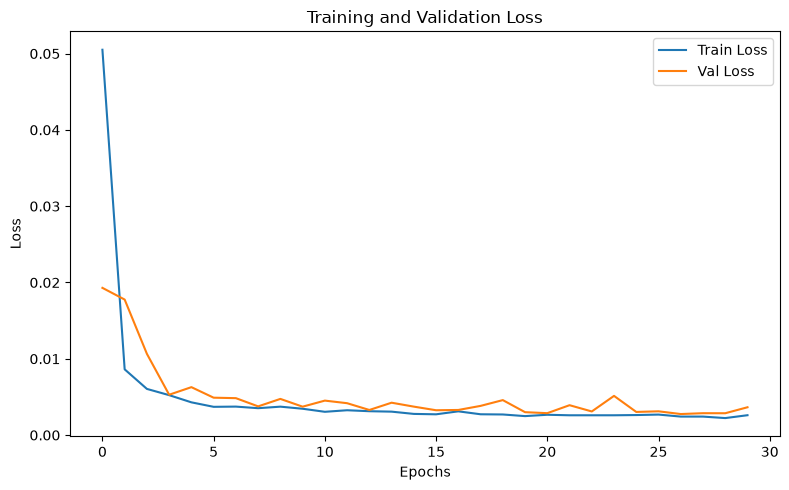

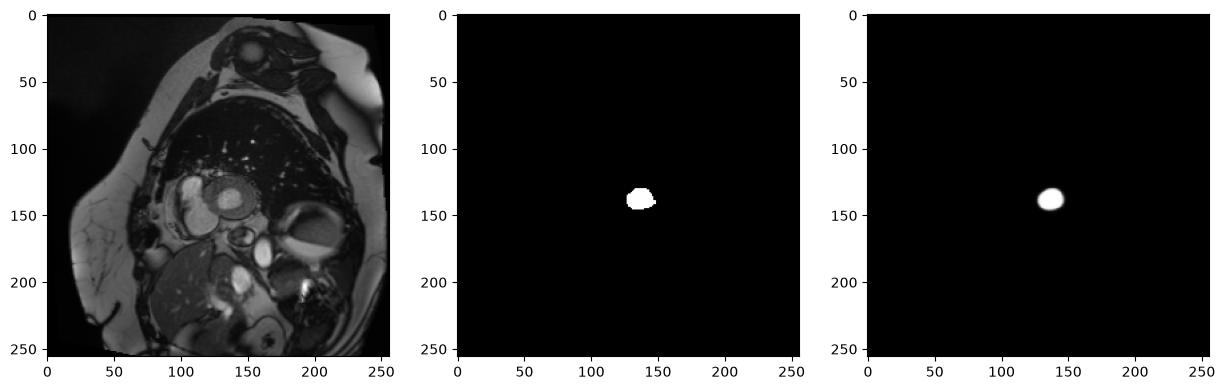

Evaluation Complete
Mean Error: 2.01 ± 5.44 pixels
Min Error:  0.02 pixels
Max Error:  97.16 pixels
----------------------------------------


In [102]:
plot_metrics(metrics)
show_segmentation(model, ds_test, im_number=21)
mean_error, min_error, max_error, std_error = evaluate_fcn1(model, dl_test)
print("Evaluation Complete")
print(f"Mean Error: {mean_error:.2f} ± {std_error:.2f} pixels")
print(f"Min Error:  {min_error:.2f} pixels")
print(f"Max Error:  {max_error:.2f} pixels")
print("-" * 40)


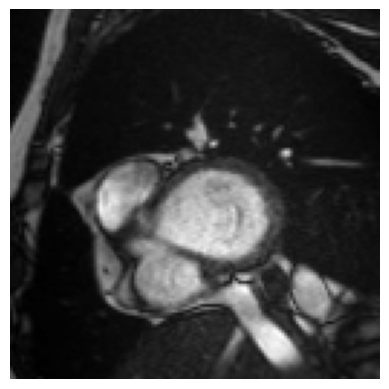

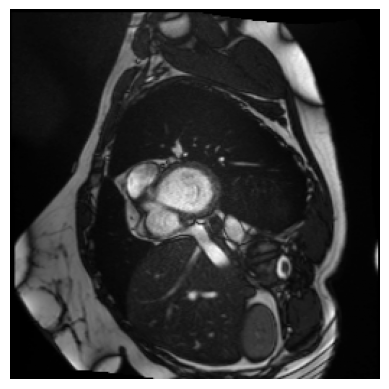

In [59]:
img, mask, _ = ds_test[0]  # ejemplo de una imagen
img_np = img.squeeze(0).cpu().numpy()

with torch.no_grad():
    output = model(img.unsqueeze(0).to(device))
    prob = torch.sigmoid(output).squeeze().cpu().numpy()

pred_mask = (prob > 0.5).astype(np.uint8)
centroid = calculate_centroid(pred_mask)

if centroid is not None:
    crop = crop_center(
        img_np,
        x_center=centroid[1],
        y_center=centroid[0],
        size=ROI_SIZE,
    )
    plt.imshow(crop, cmap="gray")
    plt.axis("off")
    plt.show()
else:
    print("No se encontró un centro para recortar")

fig, ax = plt.subplots()
ax.set_axis_off()
ax.imshow(img_np, cmap="gray")
plt.show()

## 2. FCN2:


### 2.1. FCN2 - Architecture


In [ ]:
class DoubleEncoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

    def forward(self, x, skip=None):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        skip = x
        x = self.pool(x)
        return x, skip


class DecoderDouble(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv1 = nn.Conv2d(out_channels * 2, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat((x, skip), dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x


class DecoderSingle(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv1 = nn.Conv2d(out_channels * 2, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat((x, skip), dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        return x


class InceptionModule(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=1),
            nn.Conv2d(16, 24, kernel_size=3, padding=1),
            nn.Conv2d(24, 24, kernel_size=3, padding=1),
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, 12, kernel_size=1),
            nn.Conv2d(12, 16, kernel_size=5, padding=2),
        )
        self.branch3 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, 8, kernel_size=1),
        )
        self.branch4 = nn.Conv2d(in_channels, 16, kernel_size=1)

    def forward(self, x):
        return torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1
        )


class FCN2Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Shared Contracting Path -  Encoder columnxrow
        self.encoder11 = DoubleEncoder(1, 16)
        self.encoder12 = DoubleEncoder(16, 32)
        self.encoder13 = DoubleEncoder(32, 64)
        self.encoder14 = DoubleEncoder(64, 128)

        # Bottleneck 4
        self.bottleneck1 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn_b1 = nn.BatchNorm2d(256)
        self.bottleneck2 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn_b2 = nn.BatchNorm2d(256)
        self.relu = nn.ReLU()

        # --- Expanding Paths (Parallel, independent decoders) ---
        # All paths use DecoderDouble as per the diagram showing 2 convolutions per level

        # Path 4 (Up-sampling from 256 channels)
        self.p4_up1 = DecoderDouble(256, 128)
        self.p4_up2 = DecoderDouble(128, 64)
        self.p4_up3 = DecoderDouble(64, 32)
        self.p4_up4 = DecoderDouble(32, 16)

        # Path 3 (Up-sampling from 128 channels)
        self.p3_up1 = DecoderDouble(128, 64)
        self.p3_up2 = DecoderDouble(64, 32)
        self.p3_up3 = DecoderDouble(32, 16)

        # Path 2 (Up-sampling from 64 channels)
        self.p2_up1 = DecoderDouble(64, 32)
        self.p2_up2 = DecoderDouble(32, 16)

        # Path 1 (Up-sampling from 32 channels)
        self.p1_up1 = DecoderDouble(32, 16)

        # Inception Module and Final Projection
        # Concatenates 16 channels from each of the 4 paths = 64 input channels
        self.inception = InceptionModule(64)
        # Map to 2 classes (LV cavity and Myocardium)
        self.final_conv = nn.Conv2d(64, 2, 3, padding=1)
        self.sigmoid = nn.Sigmoid()

        # init weights AFTER all layers exist
        self.apply(self.init_weights)

    def forward(self, x):
        # Enconder + skips conections
        x_pool1, s1 = self.encoder11(x)
        x_pool2, s2 = self.encoder12(x_pool1)
        x_pool3, s3 = self.encoder13(x_pool2)
        x_pool4, s4 = self.encoder14(x_pool3)

        # Bottleneck 4
        bottleneck4 = self.bottleneck1(x_pool4)
        bottleneck4 = self.bn_b1(bottleneck4)
        bottleneck4 = self.relu(bottleneck4)
        bottleneck4 = self.bottleneck2(bottleneck4)
        bottleneck4 = self.bn_b2(bottleneck4)
        bottleneck4 = self.relu(bottleneck4)

        # b4 = self.relu(self.bn_b1(self.bottleneck1(x_pool4)))
        # b4 = self.relu(self.bn_b2(self.bottleneck2(b4)))

        # 3. Independent Forward Propagation per Expanding Path
        # No paths are mixed until the final concatenation

        # Path 4
        d4 = self.p4_up1(bottleneck4, s4)
        d4 = self.p4_up2(d4, s3)
        d4 = self.p4_up3(d4, s2)
        d4_out = self.p4_up4(d4, s1)

        # Path 3
        d3 = self.p3_up1(s4, s3)
        d3 = self.p3_up2(d3, s2)
        d3_out = self.p3_up3(d3, s1)

        # Path 2
        d2 = self.p2_up1(s3, s2)
        d2_out = self.p2_up2(d2, s1)

        # Path 1
        d1_out = self.p1_up1(s2, s1)

        # 4. Final Concatenation, Inception processing, and Sigmoid probability map
        out = torch.cat((d4_out, d3_out, d2_out, d1_out), dim=1)
        out = self.inception(out)
        logits = self.final_conv(out)
        # prob_map = self.sigmoid(logits)

        return logits

    def init_weights(self, m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            init.kaiming_normal_(m.weight, nonlinearity="relu")


In [ ]:
img_size = (128, 128)
batch_size = 8

torchinfo.summary(FCN1Net(), input_size=(batch_size, 1, img_size[0], img_size[1]))

### 2.2 FCN2 - Dataset


In [ ]:
# Create Dataset - FCN2
class FCN2Dataset(Dataset):
    def __init__(self, filepath, transform=None):
        self.slices = []
        self.transform = transform

        for path in filepath:
            img, _ = self._sitk_load(path)
            mask_path = path.replace(".nii.gz", "_gt.nii.gz")
            mask, _ = self._sitk_load(mask_path)

            new_mask = np.full_like(mask, 255)  # 255 = "ignorar" (fondo + VD)
            new_mask[mask == 2] = 0  # Cavidad -> clase 0
            new_mask[mask == 3] = 1  # Miocardio -> clase 1
            mask = new_mask

            # regex to find info
            patient = path.split("/")[-2]
            frame = int(re.search(r"frame(\d+)", path).group(1))

            # TODO: i think i could delete this (review before)
            for i in range(img.shape[0]):
                self.slices.append(
                    {
                        "image": img[i],
                        "mask": mask[i],
                        "patient": patient,
                        "frame": frame,
                        "slice_idx": i,
                    }
                )

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        item = self.slices[idx]
        img = item["image"]
        mask = item["mask"]  # mask tiene 0, 1, 255

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        # 1. Crear máscaras binarias para cada canal [H, W]
        # El 255 se vuelve 0 en ambos canales (no es ni cavidad ni miocardio)
        canal_cavidad = (mask == 0).astype(np.float32)
        canal_miocardio = (mask == 1).astype(np.float32)

        # 2. Apilar para obtener [2, 128, 128]
        mask_final = np.stack([canal_cavidad, canal_miocardio], axis=0)

        # Convertir a Tensores
        img = torch.from_numpy(img).float().unsqueeze(0)  # [1, 128, 128]
        mask = torch.from_numpy(mask_final).float()  # [2, 128, 128]

        metadata = {
            "patient": item["patient"],
            "frame": item["frame"],
            "slice_idx": item["slice_idx"],
        }
        return img, mask, metadata

    def _sitk_load(
        self,
        filepath,
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        """Loads an image using SimpleITK and returns the image and its metadata.

        Args:
            filepath: Path to the image.

        Returns:
            - ([N], H, W), Image array.
            - Collection of metadata.
        """
        # Load image and save info
        image = SimpleITK.ReadImage(str(filepath))
        info = {
            "origin": image.GetOrigin(),
            "spacing": image.GetSpacing(),
            "direction": image.GetDirection(),
        }

        # Extract numpy array from the SimpleITK image object
        im_array = np.squeeze(SimpleITK.GetArrayFromImage(image))

        return im_array, info


In [ ]:
BATCHSIZE = 8
EPOCHS = 20

# TODO: Temporal:
resized = A.Compose(
    [A.Resize(height=128, width=128)]
)  # we are doing this because i haven joined the output of FCN1 here


# Choose 10 random patients from pattient 001 to patiento 100 for the validation set
random.seed(42)
patients = list(range(1, 101))  # patient001 - patient100
val_patients = random.sample(patients, 10)

train_paths = []
validation_paths = []

# Extracts the patient number from the file path and checks whether that patient belongs to the validation set.
for f in train_val_paths:
    patient = int(f.split("patient")[1][:3])
    if patient in val_patients:
        validation_paths.append(f)
    else:
        train_paths.append(f)

# ------

ds_train = FCN2Dataset(train_paths, resized)
ds_validation = FCN2Dataset(validation_paths, resized)

test_image_paths = [file for file in img_paths if "testing" in file]
test_image_sorted = sorted(
    test_image_paths, key=lambda x: int(re.search(r"patient(\d+)", x).group(1))
)  # Sorted test image by patients : No estoy muy segura si lo necesito
ds_test = FCN2Dataset(test_image_sorted, resized)

### 2.3. FCN2 - Training


In [ ]:
print("Training...")


def train_model_fcn2(
    model,
    train_loader,
    validation_loader,
    learning_rate=6e-4,
    criterion=nn.CrossEntropyLoss(),
    epochs=20,
):
    """
    Train the model on the training set and validate it on the validation set.

    Return the training and validation metrics.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    metrics = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(epochs):
        start = time.time()
        losses = 0
        model.train()
        for img, mask, _ in train_loader:
            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, mask)
            loss.backward()
            optimizer.step()
            losses += loss.item()

        metrics["train_loss"].append(losses / len(train_loader))
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for img, mask, _ in validation_loader:
                output = model(img)
                val_loss += criterion(output, mask).item()
            metrics["val_loss"].append(val_loss / len(validation_loader))

        print(
            f"Epoch {epoch + 1} in {time.time() - start:.2f} s, Train Loss: {metrics['train_loss'][-1]:.5f}, Val Loss: {metrics['val_loss'][-1]:.5f}"
        )

    return metrics


model = FCN2Net()
optimizer = torch.optim.Adam(model.parameters(), lr=6e-4)
criterion = nn.BCEWithLogitsLoss()

dataloader_args = {
    "batch_size": BATCHSIZE,
}

# shuffle = True  the data is randomly shuffled before each epoch.
dl_train_fcn2 = DataLoader(ds_train, **dataloader_args, shuffle=True)
dl_val_fcn2 = DataLoader(ds_validation, **dataloader_args, shuffle=False)
dl_test_fcn2 = DataLoader(ds_test, **dataloader_args, shuffle=False)


metrics = train_model_fcn2(
    model,
    dl_train_fcn2,
    dl_val_fcn2,
    learning_rate=6e-4,
    criterion=criterion,
    epochs=EPOCHS,
)
print("Training is done")

### 2.4. Model evaluation FCN2


#### Define functions for evaluation:

- Show segmentation
- Calculate the loss function (training and validation)


In [ ]:
def plot_metrics_fcn2(metrics):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(metrics["train_loss"], label="Train Loss")
    ax.plot(metrics["val_loss"], label="Val Loss")

    ax.set_title("Training and Validation Loss")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
def show_segmentation_fcn2(model, dataset, im_number=0):
    img, mask, _ = dataset[im_number]
    img = img.squeeze().cpu()

    # 2. Preparar Predicción
    with torch.no_grad():
        pred = (
            F.sigmoid(model(img.unsqueeze(0).unsqueeze(0).to(img.device)))
            .squeeze()
            .cpu()
        )
        pred = (pred > 0.5).float()  # Binarizar

    # 3. Función auxiliar para convertir (2, 128, 128) a (128, 128, 3)
    def mask_to_rgb(m):
        # m es (2, 128, 128). Creamos un lienzo RGB (128, 128, 3)
        h, w = m.shape[1], m.shape[2]
        rgb = np.zeros((h, w, 3))
        rgb[..., 0] = m[0]  # Canal 0 -> Rojo
        rgb[..., 1] = m[1]  # Canal 1 -> Verde
        return rgb

    # 4. Graficar
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Original
    axs[0].imshow(img, cmap="gray")
    axs[0].set_title("Original")

    # Ground Truth (se pinta sobre la imagen)
    axs[1].imshow(img, cmap="gray")
    axs[1].imshow(mask_to_rgb(mask), alpha=0.5)
    axs[1].set_title("Ground Truth (Rojo: Cavidad, Verde: Mio)")

    # Predicción (se pinta sobre la imagen)
    axs[2].imshow(img, cmap="gray")
    axs[2].imshow(mask_to_rgb(pred), alpha=0.5)
    axs[2].set_title("Predicción")

    plt.show()


In [ ]:
plot_metrics_fcn2(metrics)
show_segmentation_fcn2(model, dl_test_fcn2, im_number=12)